In [124]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import torch
import os
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer, utils
from transformers import AutoTokenizer
from dictionary_learning.scae import SCAESuite, MergedSCAESuite # Your SCAESuite class
from datasets import load_dataset
from dictionary_learning.buffer import chunk_and_tokenize
from interp.interp_utils import (
    load_tokenized_dataset,
    collect_activations_and_tokens,
    generate_feature_dashboard,
    plot_alive_feature_percentage,
    get_fvu_from_wandb,
    calculate_global_connection_stats,
    plot_upstream_connection_histograms,
    calculate_module_connection_stats_from_file,
    plot_connections_vs_fvu,
    find_non_dead_features,
    display_feature_and_upstream
)

torch.set_grad_enabled(False)

# --- Configuration ---
MODEL_NAME = "EleutherAI/pythia-70m"
PATH_TO_PILE = "/root/dictionary_learning/pile-uncopyrighted"
# For local pile, you might need to specify data_files if it's a collection of .jsonl.gz
# e.g., data_files = {"train": ["/path/to/pile/train/00.jsonl.gz", ...]}
# For HF streaming, data_files can be None.
DATA_FILES = None # Set to list of local file paths if using local pile and not streaming
STREAM_PILE = True # If True, streams from HF. If False and DATA_FILES is None, loads non-streamed from HF.
                   # If DATA_FILES is set, STREAM_PILE=True will stream from those local files.
SEQ_LEN = 128
NUM_SAMPLES_TO_LOAD = 5000 # How many sequences to prepare from the dataset
NUM_SAMPLES_TO_PROCESS = 5000 # How many sequences to run through the suite for activations (max_batches_to_process * batch_size)
BATCH_SIZE_COLLECT = 64
OUTPUT_ACTIVATIONS_DIR = "output_activations_pile"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Dashboards

In [3]:
# # --- Initialize Model and Tokenizer ---
model = HookedTransformer.from_pretrained(MODEL_NAME, device=DEVICE, dtype=torch.bfloat16)
model.eval()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer = utils.get_tokenizer_with_bos(tokenizer)

suite = SCAESuite.from_pretrained(
    repo_id="jacobcd52/pythia-70m_warmup0.3_k16_mask0.0003_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005",
    model=model,
    device=DEVICE,
    dtype=torch.bfloat16
)

print(f"Using device: {DEVICE}")
os.makedirs(OUTPUT_ACTIVATIONS_DIR, exist_ok=True)

Loaded pretrained model EleutherAI/pythia-70m into HookedTransformer
Using device: cuda


In [4]:
raw_dataset = load_dataset(
    PATH_TO_PILE,
    split=f"train[:1%]",
).shuffle(seed=42)

tokenized_dataset = chunk_and_tokenize(
    dataset=raw_dataset,
    tokenizer=tokenizer,
    text_key="text",
    max_length=SEQ_LEN,
    num_proc=max(1, os.cpu_count() // 2),
    load_from_cache_file=True
)

if len(tokenized_dataset) > NUM_SAMPLES_TO_PROCESS:
    dataset_to_process = tokenized_dataset.select(range(NUM_SAMPLES_TO_PROCESS))
else:
    dataset_to_process = tokenized_dataset

In [5]:
toks_list = []
iterable_dataset = iter(dataset_to_process)
for _ in range(512):
    toks_list.append(next(iterable_dataset)['input_ids'])
toks = torch.stack(toks_list[:256], dim=0)
toks_test = torch.stack(toks_list[256:], dim=0)


layer = 3
ae = suite.module_dict[f'attn_{layer}'].ae
hook_pt = f'blocks.{layer}.hook_attn_out'
_, cache = model.run_with_cache(toks, return_type="loss", names_filter=[hook_pt])
act = cache[hook_pt]
f = ae.encode(act)
recons = ae.decode(f)
fvu = (act - recons).pow(2).sum() / (act - act.mean(dim=[0, 1])).pow(2).sum()

print("SAE FVU: ", fvu)

_, cache_test = model.run_with_cache(toks_test, return_type="loss", names_filter=[hook_pt])
act_test = cache_test[hook_pt]

# Compute PCA on training activations
q = 16
U, S, V = torch.pca_lowrank(act.float().reshape(-1, act.shape[-1]), q=q)
V = V.to(act.dtype)
# Project test activations onto PCA components
act_test_flat = act_test.reshape(-1, act_test.shape[-1])
act_test_proj = act_test_flat @ V
# Compute variance explained
total_var = (act_test_flat - act_test_flat.mean(dim=[0, 1])).pow(2).sum()
explained_var = (act_test_proj - act_test_proj.mean(dim=[0, 1])).pow(2).sum()
print(f"FVU of top {q} PCA components: {1 - explained_var/total_var:.3f}")

SAE FVU:  tensor(0.2500, device='cuda:0', dtype=torch.bfloat16)
FVU of top 16 PCA components: 0.484


In [6]:
# --- Collect Activations ---
# Determine the number of batches to process
max_batches = NUM_SAMPLES_TO_PROCESS // BATCH_SIZE_COLLECT

# Collect for sparse_false mode
print("Starting activation collection for sparse_false mode...")
collect_activations_and_tokens(
    suite=suite,
    model=model,
    tokenizer=tokenizer,
    dataset=dataset_to_process,
    device=DEVICE,
    output_dir=OUTPUT_ACTIVATIONS_DIR,
    run_mode_sparse=False,
    batch_size=BATCH_SIZE_COLLECT,
    max_batches_to_process=max_batches
)
print("Finished activation collection for sparse_false mode.")

# Collect for sparse_true mode
print("\\nStarting activation collection for sparse_true mode...")
collect_activations_and_tokens(
    suite=suite,
    model=model,
    tokenizer=tokenizer,
    dataset=dataset_to_process,
    device=DEVICE,
    output_dir=OUTPUT_ACTIVATIONS_DIR,
    run_mode_sparse=True,
    batch_size=BATCH_SIZE_COLLECT,
    max_batches_to_process=max_batches
)
print("Finished activation collection for sparse_true mode.")

Starting activation collection for sparse_false mode...
Starting activation collection. Mode: Non-sparse
Saving to: output_activations_pile/sparse_false
Processed and saved batch 0
Processed and saved batch 10
Processed and saved batch 20
Processed and saved batch 30
Processed and saved batch 40
Processed and saved batch 50
Processed and saved batch 60
Processed and saved batch 70
Reached max_batches_to_process: 78. Stopping.
Finished activation collection for mode: Non-sparse.
Finished activation collection for sparse_false mode.
\nStarting activation collection for sparse_true mode...
Starting activation collection. Mode: Sparse
Saving to: output_activations_pile/sparse_true
Processed and saved batch 0
Processed and saved batch 10
Processed and saved batch 20
Processed and saved batch 30
Processed and saved batch 40
Processed and saved batch 50
Processed and saved batch 60
Processed and saved batch 70
Reached max_batches_to_process: 78. Stopping.
Finished activation collection for mo

In [5]:
activations_directory = OUTPUT_ACTIVATIONS_DIR
non_dead_feature_lists = find_non_dead_features(activations_directory)

Processing mode: sparse_true...
Processing mode: sparse_false...
Finished finding non-dead features.


In [230]:
non_dead_feature_lists['sparse_true']['attn_2'][:16]

[0, 3, 4, 6, 7, 9, 11, 13, 15, 16, 18, 19, 20, 22, 25, 27]

In [251]:
# --- Generate Feature Dashboard ---
# Choose which activations to analyze (sparse or non-sparse)
mode_to_analyze = "sparse_true" 
activations_path = os.path.join(OUTPUT_ACTIVATIONS_DIR, mode_to_analyze)
module_to_inspect = "attn_0"
feature_idx_in_module = 2956 

# Check if the activations path for the chosen mode exists
if not os.path.exists(activations_path):
    print(f"Activations path {activations_path} does not exist. Run collection for this mode first.")
else:
    # Check if there are any batch folders in the activations_path
    batch_folders_exist = any(d.startswith("batch_") for d in os.listdir(activations_path))
    if not batch_folders_exist:
        print(f"No batch data found in {activations_path}. Ensure activation collection was successful.")
    else:
        print(f"Generating dashboard using activations from: {activations_path}")
        generate_feature_dashboard(
            module_name_str=module_to_inspect,
            feature_idx_in_module=feature_idx_in_module,
            activations_base_dir=activations_path,
            tokenizer=tokenizer,
            model=model,
            suite=suite,
            k_top_contexts=50,
            k_top_connections=5,
            context_window_size=40, # Number of tokens around the max activating one
            tight_layout=True,
        )

Generating dashboard using activations from: output_activations_pile/sparse_true
Generating dashboard for: attn_0, Feature Index: 2956


In [249]:
activations_path = 'feature_data/pythia-70m_warmup0.3_k16_mask0.0003_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005/sparse_true'
non_dead_features_file_path = "/root/dictionary_learning/interp/feature_data/pythia-70m_warmup0.3_k16_mask0.0003_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005_non_dead_features.json"

# Replace with a module and feature you want to inspect.
display_feature_and_upstream(
    module_name="attn_0",
    feature_idx=2956, # Example feature index
    suite=suite,
    model=model,
    tokenizer=tokenizer,
    activations_base_dir=activations_path,
    non_dead_features_file_path=non_dead_features_file_path,
    k_upstream_features=3,
    k_top_contexts=7, # You can override dashboard defaults
    k_top_connections=5,
    context_window_size=300,
    depth=0,
    tight_layout_context_spacing_px=20
)

Generating dashboard for primary feature: attn_0/2956
Generating dashboard for: attn_0, Feature Index: 2956


# Plots

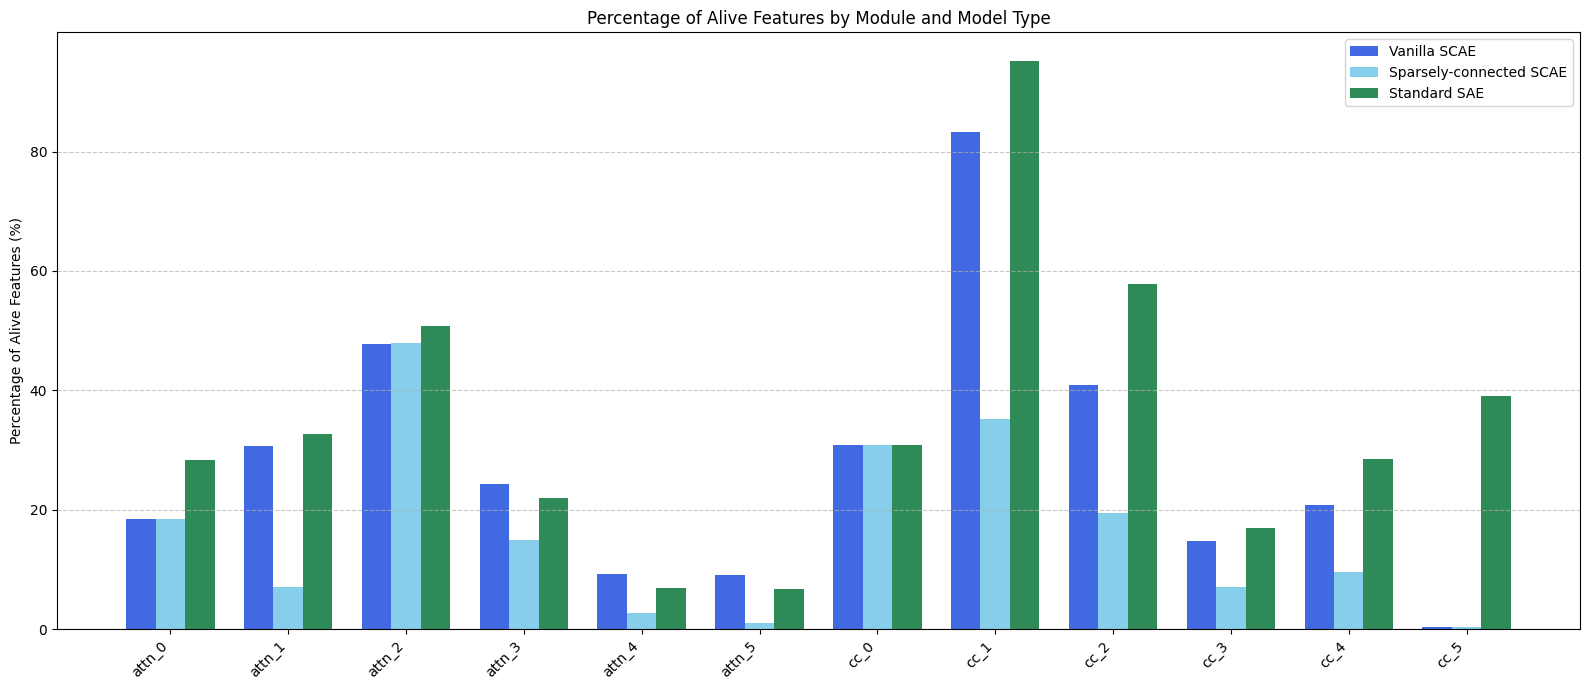

In [119]:
plot_alive_feature_percentage(
    suite, 
    "/root/dictionary_learning/interp/feature_data/pythia-70m_warmup0.3_k16_mask0.0003_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005_non_dead_features.json",
    "/root/dictionary_learning/interp/feature_data/pythia-70m_warmup0.3_k16_mask0_fact_fvu0.0_fvu_sparse0.0_fvu1.0_lr0.0005_non_dead_features.json"
    )

Generating upstream connection histograms for mode: sparse_true


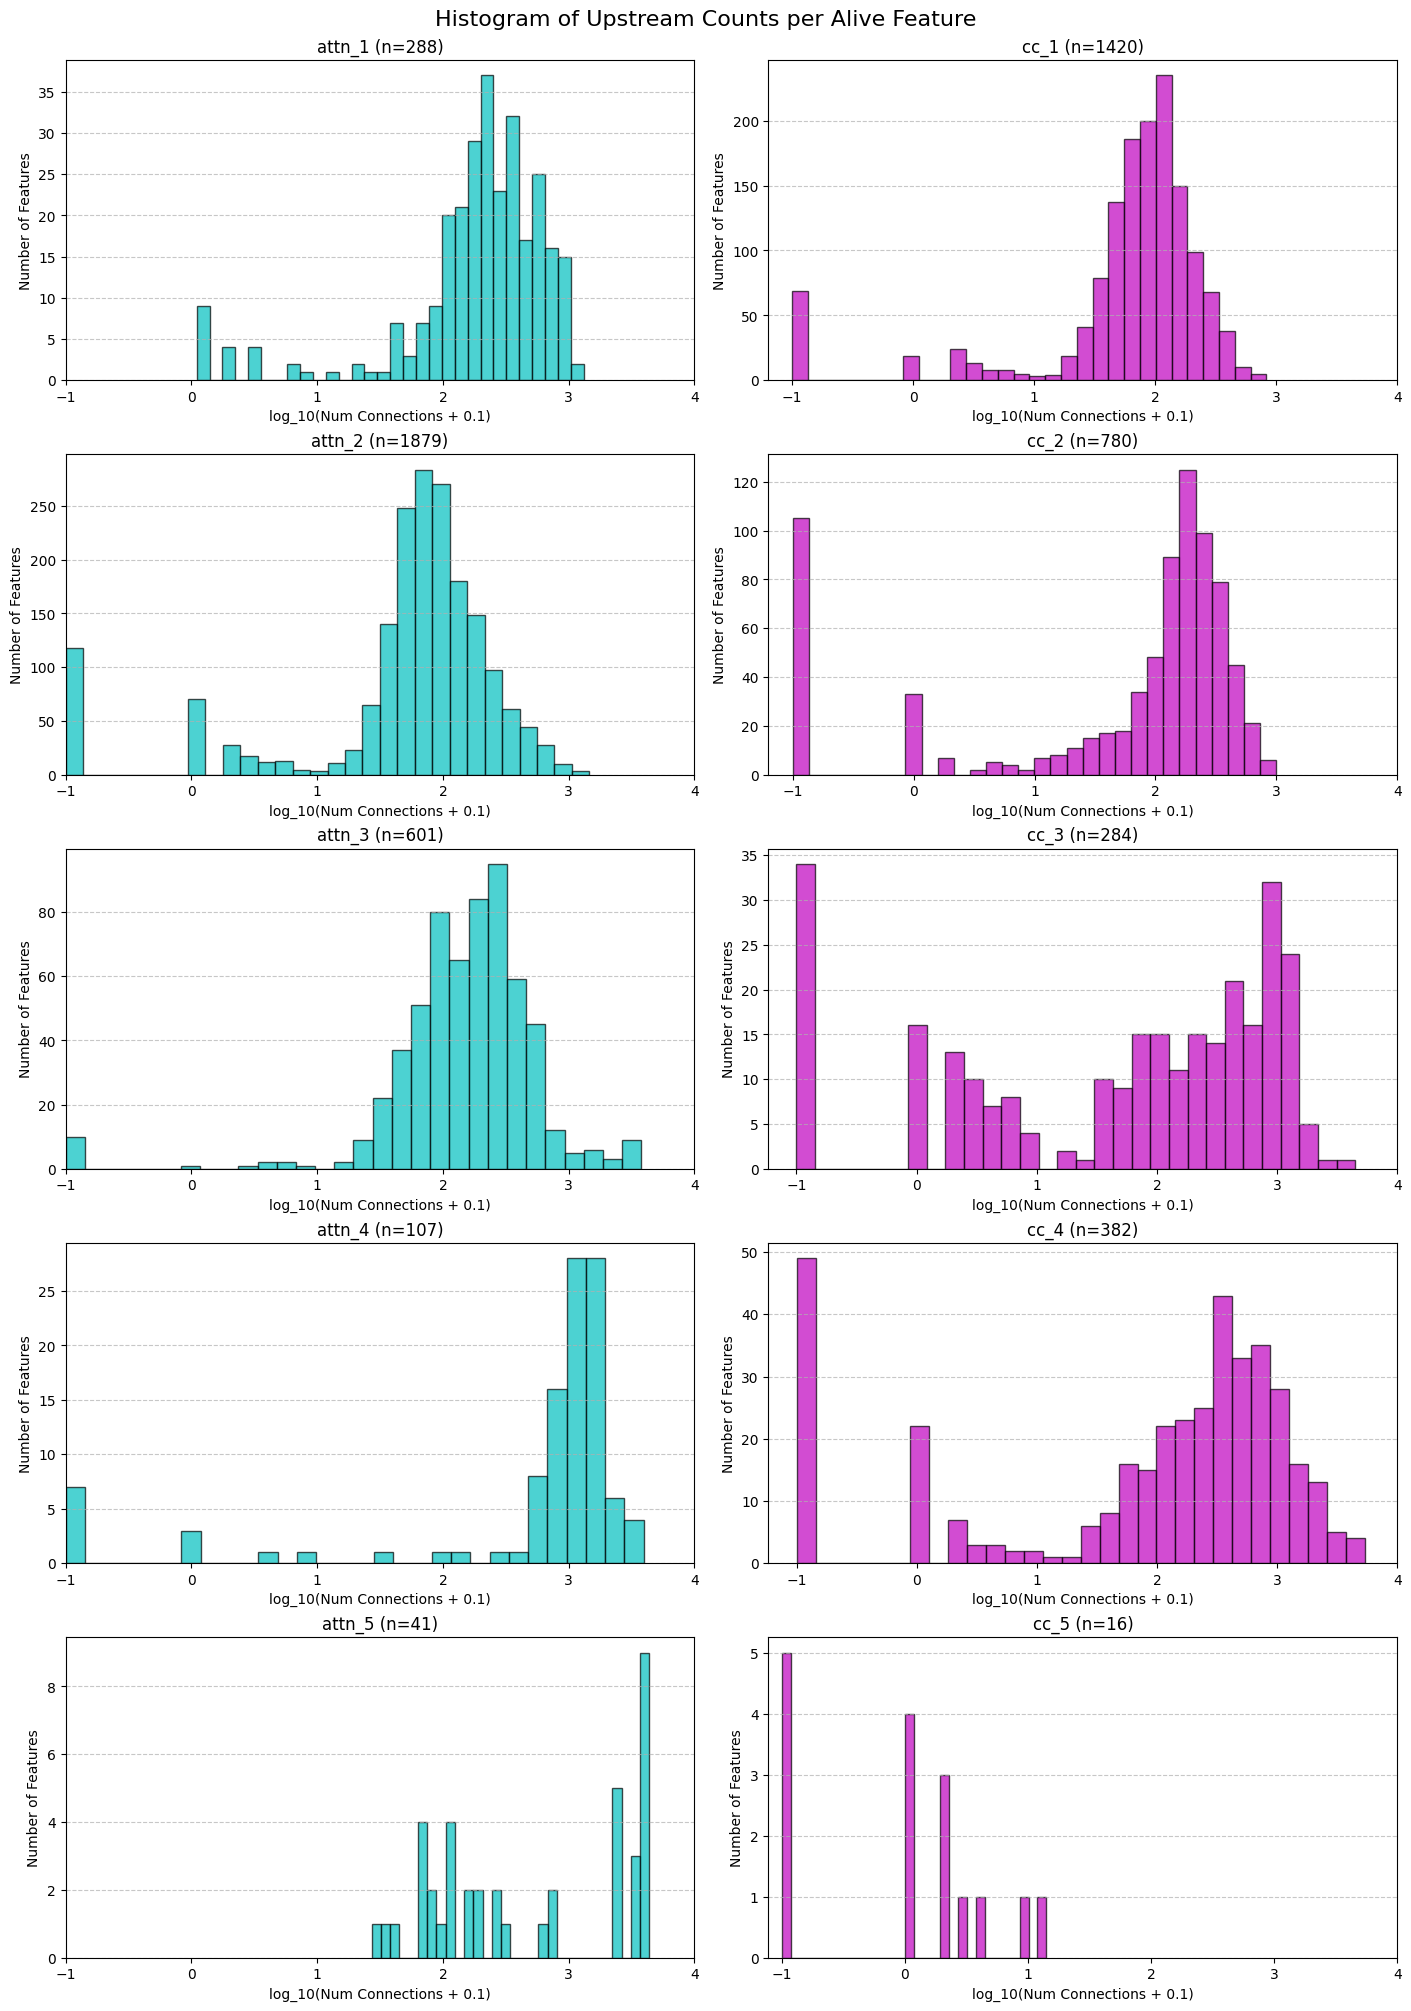

In [319]:
plot_upstream_connection_histograms(suite, non_dead_feature_lists)

In [53]:
run_ids = [
    "2nzm8aww",
    # "9tlyf1bm",
    "7f6i9wrq",
    "fsrl695z",
    "wrk57krc",
    "oakj0wkr",
    "2nzm8aww"
]

fvu_dict = get_fvu_from_wandb(run_ids, last_n=10)

100%|██████████| 6/6 [00:03<00:00,  1.52it/s]


In [44]:
standard_sae_fvu_dict = get_fvu_from_wandb(["ux14r2wq"], last_n=10)

100%|██████████| 1/1 [00:00<00:00,  1.30it/s]


In [ ]:
baseline_fvu = standard_sae_fvu_dict['warmup0.3_k16_mask0_fact_fvu0.0_fvu_sparse0.0_fvu1.0_lr0.0005']['non_sparse_fvu']

In [54]:
C_and_fvu_list = []

for run_name, fvu in fvu_dict.items():
    file_path = "feature_data/pythia-70m_" + f"{run_name}_non_dead_features.json"
    connection_stats = calculate_module_connection_stats_from_file(file_path)
    C = connection_stats['overall']
    C_and_fvu_list.append((C, fvu))

Using device: cuda
Loading base model: EleutherAI/pythia-70m...


Loaded pretrained model EleutherAI/pythia-70m into HookedTransformer
Loading suite from: jacobcd52/pythia-70m_warmup0.3_k16_mask0_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005...
Loading non-dead features from: feature_data/pythia-70m_warmup0.3_k16_mask0_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005_non_dead_features.json
Calculating connection stats for mode: sparse_true...
Using device: cuda
Loading base model: EleutherAI/pythia-70m...


Loaded pretrained model EleutherAI/pythia-70m into HookedTransformer
Loading suite from: jacobcd52/pythia-70m_warmup0.3_k16_mask0.0001_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005...
Loading non-dead features from: feature_data/pythia-70m_warmup0.3_k16_mask0.0001_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005_non_dead_features.json
Calculating connection stats for mode: sparse_true...
Using device: cuda
Loading base model: EleutherAI/pythia-70m...


Loaded pretrained model EleutherAI/pythia-70m into HookedTransformer
Loading suite from: jacobcd52/pythia-70m_warmup0.3_k16_mask0.001_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005...
Loading non-dead features from: feature_data/pythia-70m_warmup0.3_k16_mask0.001_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005_non_dead_features.json
Calculating connection stats for mode: sparse_true...
Using device: cuda
Loading base model: EleutherAI/pythia-70m...


Loaded pretrained model EleutherAI/pythia-70m into HookedTransformer
Loading suite from: jacobcd52/pythia-70m_warmup0.3_k16_mask0.01_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005...
Loading non-dead features from: feature_data/pythia-70m_warmup0.3_k16_mask0.01_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005_non_dead_features.json
Calculating connection stats for mode: sparse_true...
Using device: cuda
Loading base model: EleutherAI/pythia-70m...


Loaded pretrained model EleutherAI/pythia-70m into HookedTransformer
Loading suite from: jacobcd52/pythia-70m_warmup0.3_k16_mask0.0003_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005...
Loading non-dead features from: feature_data/pythia-70m_warmup0.3_k16_mask0.0003_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005_non_dead_features.json
Calculating connection stats for mode: sparse_true...


In [55]:
fvu_dict.keys()

dict_keys(['warmup0.3_k16_mask0_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005', 'warmup0.3_k16_mask0.0001_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005', 'warmup0.3_k16_mask0.001_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005', 'warmup0.3_k16_mask0.01_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005', 'warmup0.3_k16_mask0.0003_fact_fvu0.2_fvu_sparse1.0_fvu1.0_lr0.0005'])

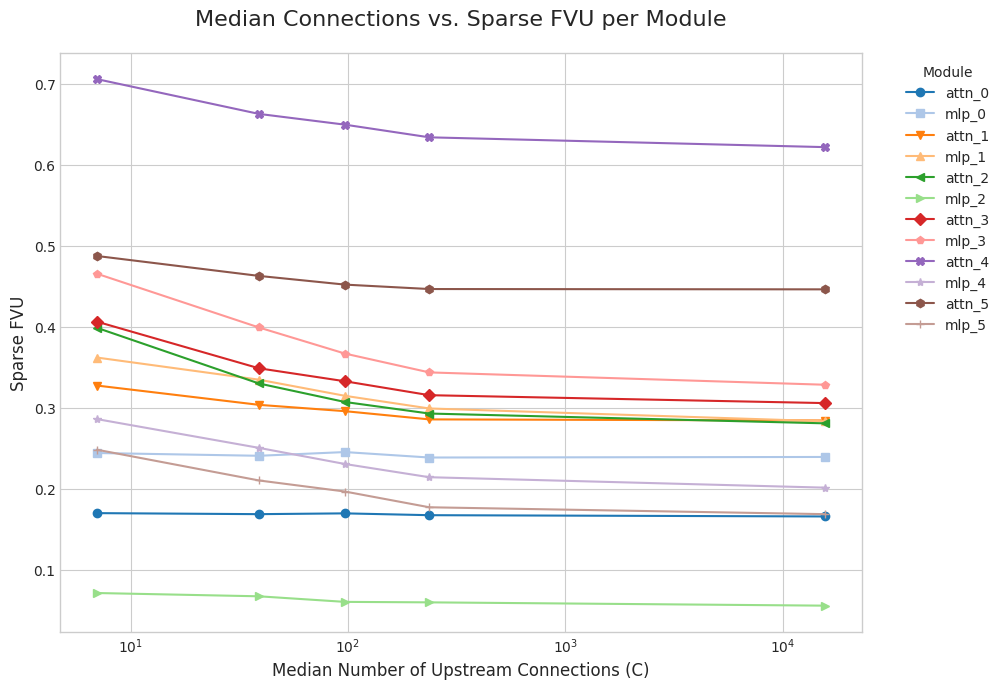

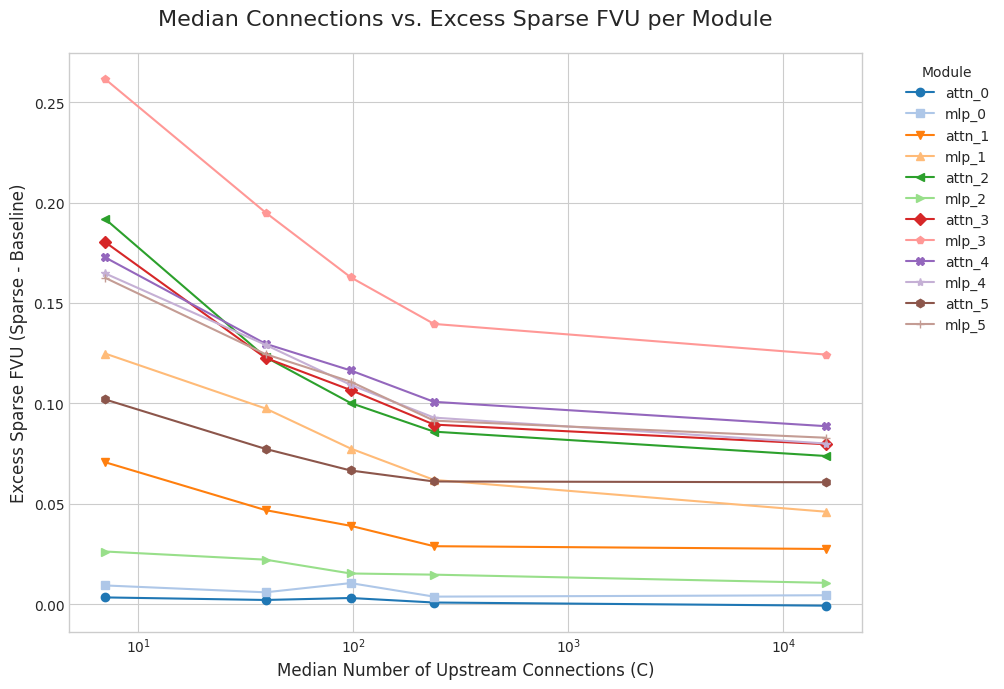

In [60]:
plot_connections_vs_fvu(C_and_fvu_list, baseline_fvu=baseline_fvu)